In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# Folder containing all scores
# ---------------------------------------
scores_root = "all_score_test"


# ---------------------------------------
# Load metrics for a single model
# ---------------------------------------
def compute_metrics(model_path):
    try:
        true = np.load(os.path.join(model_path, "true_coefs.npy"))
        pred = np.load(os.path.join(model_path, "pred_coefs_mean.npy"))
    except FileNotFoundError:
        return None
    
    mse  = np.mean((pred - true)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pred - true))

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
    }


# ---------------------------------------
# Scan all tasks and models
# ---------------------------------------
rows = []

for task in os.listdir(scores_root):
    task_path = os.path.join(scores_root, task)
    if not os.path.isdir(task_path):
        continue
    
    for model in os.listdir(task_path):
        model_path = os.path.join(task_path, model)
        if not os.path.isdir(model_path):
            continue
        
        metrics = compute_metrics(model_path)
        if metrics is None:
            continue
        
        row = {
            "Task": task,
            "Model": model,
        }
        row.update(metrics)
        rows.append(row)


# ---------------------------------------
# Build DataFrame
# ---------------------------------------
df = pd.DataFrame(rows)
df = df.sort_values(by=["Task", "MSE"]).reset_index(drop=True)
df_display = df.style.background_gradient(cmap="viridis")

df


,Task,Model,MSE,RMSE,MAE
0,scarce,MLP,0.023448,0.153127,0.066940
1,scarce,GraphSAGEGlobal,0.023986,0.154875,0.068510
2,scarce,GraphSAGE,0.024447,0.156356,0.067820
3,scarce,MLPGlobal,0.027295,0.165212,0.067877
4,scarce,GUNetGlobal,0.036281,0.190475,0.087549
5,scarce,PointNetGlobal,0.046635,0.215952,0.092531
6,scarce,PointNet,0.074442,0.272840,0.088254


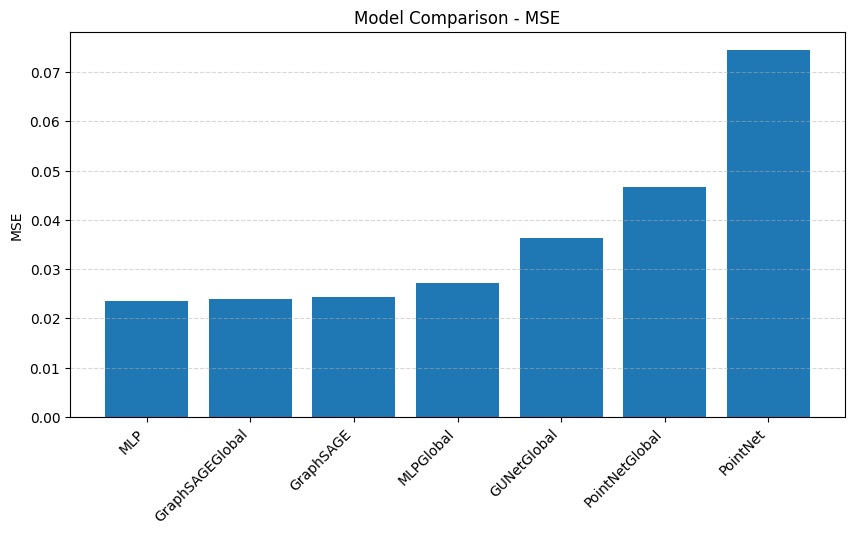

In [2]:
plt.figure(figsize=(10,5))
plt.bar(df["Model"], df["MSE"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison - MSE")
plt.ylabel("MSE")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()
